# EMA monitoring in a real mini-batch fit

This notebook fits a normal location model with mini-batch optimization and uses Liesel's integrated loss plot to show the continuous EMA monitor.

In [4]:
import jax
import jax.numpy as jnp
import optax
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl
import liesel.optim as opt

Let $e$ be `effective_window` and $N$ the configured number of batches per epoch. The EMA span $W$ and smoothing coefficients are

$$
W = \max(1, eN), \qquad
\alpha = \frac{2}{W + 1}, \qquad
\beta = 1 - \alpha.
$$

Starting from $m_0 = w_0 = 0$, mini-batch observation $t$ updates

$$
m_t = \beta m_{t-1} + \alpha L_t, \qquad
w_t = \beta w_{t-1} + \alpha, \qquad
\operatorname{EMA}_t = \frac{m_t}{w_t}.
$$

Here $L_t$ is the pre-update loss, $m_t$ its unnormalized exponentially weighted sum, $w_t$ the accumulated weight, $\alpha$ the newest-loss weight, and $\beta$ the decay applied to earlier losses. The index $t$ continues across epoch boundaries. Since $w_t = 1 - \beta^t$, the bias-correction factor $1 / w_t$ automatically approaches one without changing the update rule.

With `effective_window=20.0`, the EMA half-life is roughly 7.0 epoch equivalents. The alternative `EmaTrainLossMonitor.from_half_life(half_life=7.0)` constructor converts that half-life to an approximate span of 20.2 epoch equivalents. The span is not a hard inclusion window; older losses retain exponentially decreasing weight.

In [5]:
true_loc = 1.5
y_values = true_loc + jax.random.normal(jax.random.key(1), (256000,))
loc = lsl.Var.new_param(jnp.array(0.0), name="loc")
y = lsl.Var.new_obs(
    y_values,
    lsl.Dist(tfd.Normal, loc=loc, scale=1.0),
    name="y",
)
model = lsl.Model([y])
monitor = opt.EmaTrainLossMonitor(effective_window=20.0)
optimizer = opt.Optimizer(["loc"], optax.adam(learning_rate=1e-3))
engine = opt.LieselOptim(
    model,
    loss_monitor=monitor,
    batch_size=64,
    optimizers=[optimizer],
    stopper=opt.Stopper(epochs=500, patience=10, rtol=1e-4),
    seed=2,
    show_progress=True,
    show_step_progress=True,
    step_progress_update_every=100,
).build_engine()
result = engine.fit()

liesel.optim.engine - INFO - Initializing optimization at epoch 0
Train=1.417, Monitor=1.417 [E  53/500, B 4000/4000]:  11%|▋      | [00:07, 27272.17it/s]


`Training (epoch mean)` gives equal weight to all pre-update losses evaluated for the optimizer gradients at the successive parameter positions visited during an epoch. Each loss and gradient share the same mini-batch, position, PRNG key, and stochastic objective draw, so monitoring does not perform an independent evaluation. The epoch mean is not a complete training loss evaluated at the final epoch position. `Monitoring (training EMA)` is the continuous, bias-corrected exponential moving average of those same values, recorded at each epoch end. It may look less smooth than the epoch mean if the window size is small, because it gives recent batches more weight. It does not reset at epoch boundaries. The vertical line marks the smallest recorded monitoring loss. Its `position_min_monitor` is the associated epoch-end checkpoint, not a position whose exact loss equals the EMA. Use `result.position_final` to select the final position explicitly.

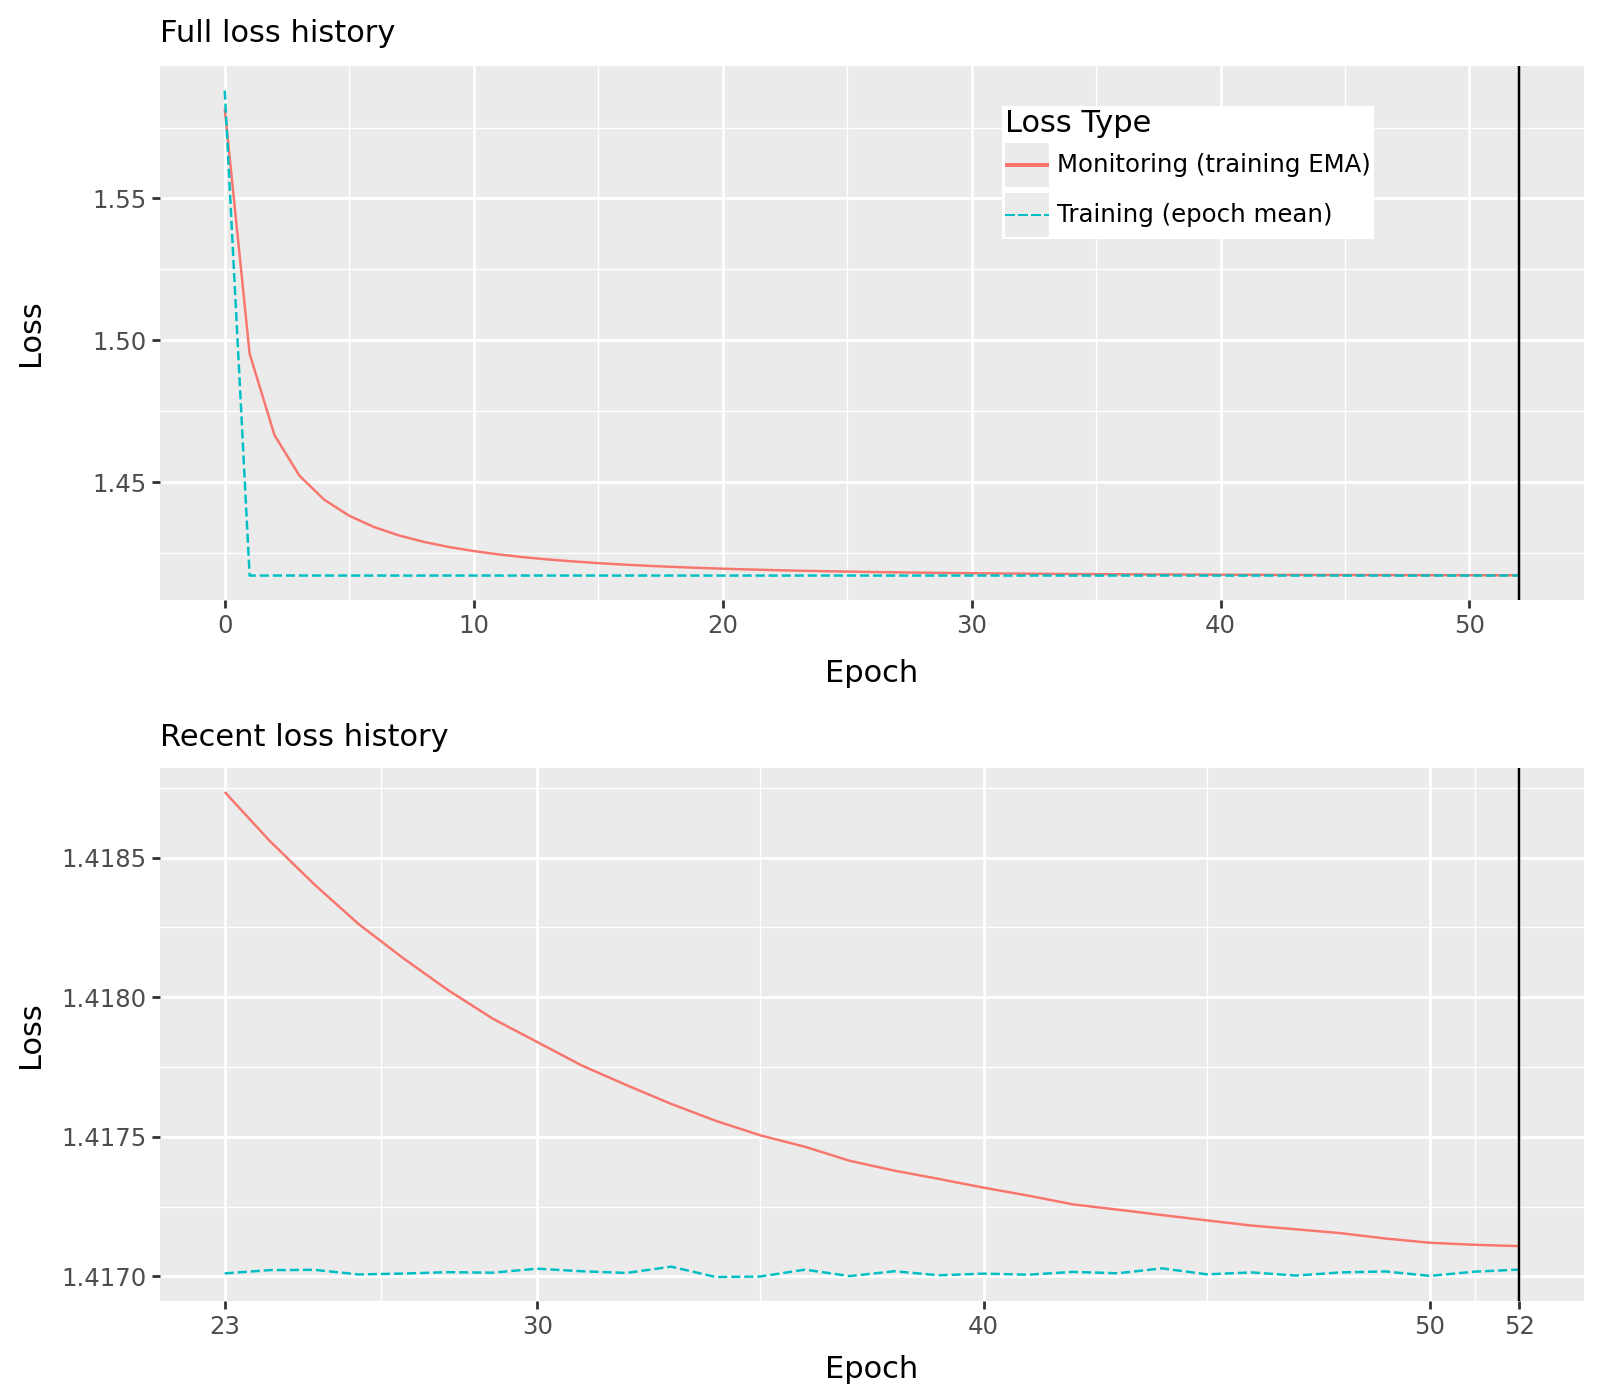

In [6]:
result.plot_loss_overview(window=30)

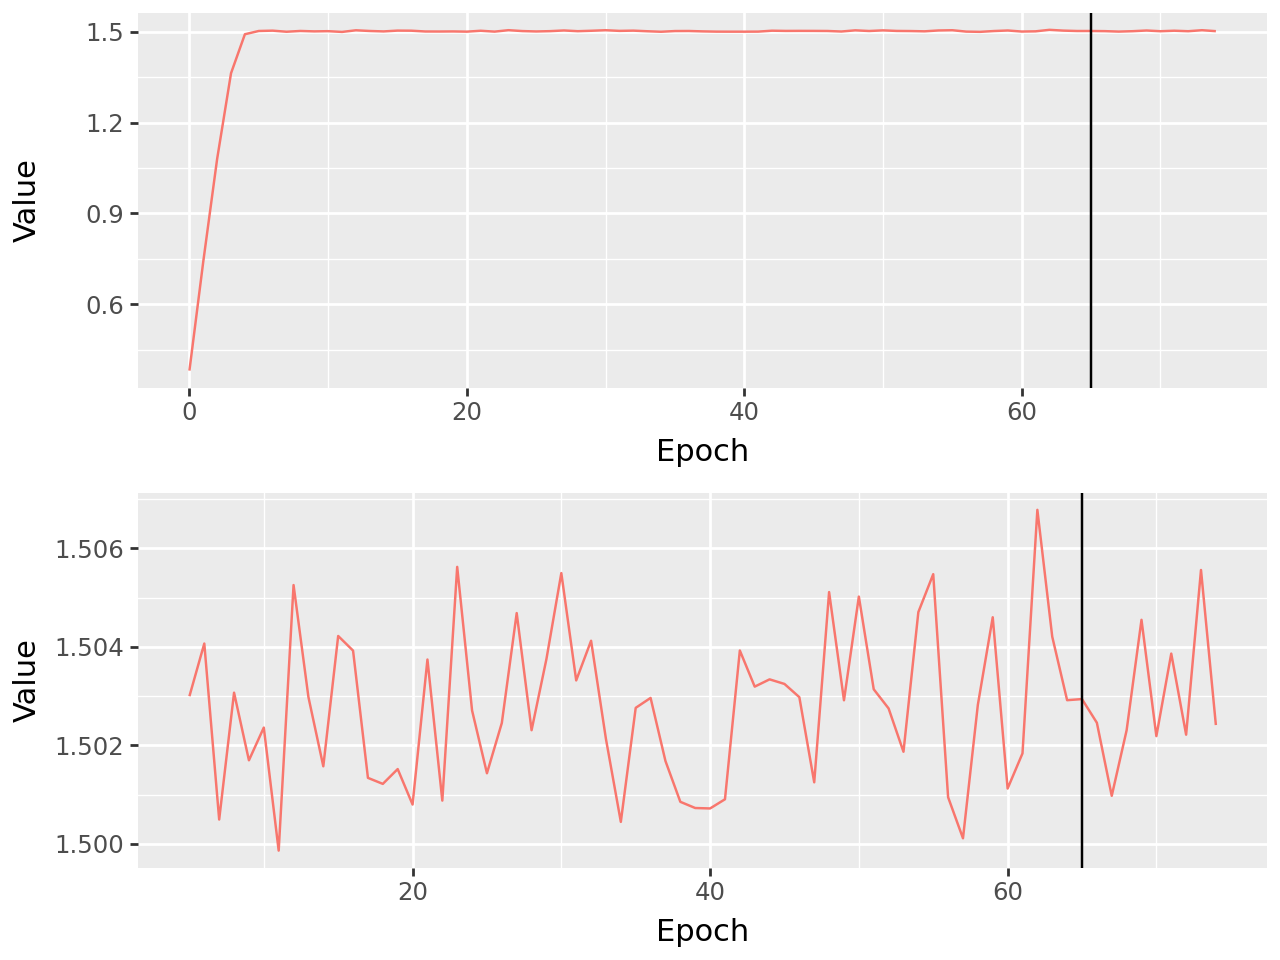

In [37]:
result.plot_params(legend=False) / result.plot_params(window=70, legend=False)